# Análisis exploratorio de datos (EDA): vuelos comerciales en EE. UU., 2018–2022

**Curso:** Herramientas de Big Data · **Proyecto final**

**Dataset:** [Flight Status Prediction (Kaggle)](https://www.kaggle.com/datasets/robikscube/flight-delay-dataset-20182022). Datos del *Marketing Carrier On-Time Performance* del Bureau of Transportation Statistics (BTS) de EE. UU. Son 5 archivos CSV (uno por año) con 61 columnas cada uno.

**Objetivo de este notebook:** unir los consolidados anuales en un único archivo parquet, revisar la calidad de los datos y dejar definida una base de análisis confiable para estudiar retrasos y cancelaciones.

## Contenido
1. Preparación del entorno
2. Unión de los 5 años en un solo parquet
3. Verificación de la unión
4. Primera mirada a los datos: estructura y tipos
5. Valores nulos
6. Origen de los nulos: vuelos cancelados y desviados
7. Columnas disponibles y cobertura por mes
8. Vuelos, cancelaciones y desvíos por año
9. Base de análisis: vuelos operados
10. Retrasos por año
11. Diagnóstico: ¿por qué 2018 tiene menos vuelos?
12. Base comparable: enero a julio
13. Conclusiones parciales y próximos pasos

## 1. Preparación del entorno

**Por qué:** los CSV pesan en total unos **10 GB**, demasiado para cargarlos completos en pandas sin riesgo de saturar la memoria. Usamos dos librerías:

- **DuckDB:** motor de consultas SQL que lee archivos grandes sin cargarlos completos en memoria. Con él unimos los CSV y hacemos las agregaciones.
- **PyArrow:** necesaria para escribir y leer el formato **parquet**, un formato columnar y comprimido. Permite leer solo las columnas que se necesitan, así que las consultas son mucho más rápidas que con CSV.

> Si ya las tienes instaladas, puedes saltarte la primera celda. Si las instalas aquí, reinicia el kernel después.

In [2]:
%pip install duckdb pyarrow

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

pd.set_option("display.max_columns", 70)   # mostrar todas las columnas
pd.set_option("display.max_rows", 100)     # mostrar hasta 100 filas

# Carpeta con los CSV: "." significa la misma carpeta donde está este notebook
carpeta_datos = Path(".")

# Archivo parquet que vamos a crear con los 5 años unidos
archivo_final = Path("Combined_Flights_2018_2022.parquet")
ruta = str(archivo_final)   # DuckDB recibe la ruta como texto

Antes de unir, confirmamos que Python encuentra los 5 archivos CSV y vemos su tamaño. Si esta lista sale vacía, hay un problema con la ruta (por ejemplo, el notebook no está en la misma carpeta que los datos).

In [4]:
archivos_csv = sorted(carpeta_datos.glob("Combined_Flights_20??.csv"))

for archivo in archivos_csv:
    print(f"{archivo.name:<30} {archivo.stat().st_size / 1e6:>8,.0f} MB")

assert len(archivos_csv) == 5, "No encontré los 5 CSV: revisa la carpeta o el nombre de los archivos"

Combined_Flights_2018.csv         1,992 MB
Combined_Flights_2019.csv         2,822 MB
Combined_Flights_2020.csv         1,747 MB
Combined_Flights_2021.csv         2,214 MB
Combined_Flights_2022.csv         1,415 MB


**Resultado:** los cinco archivos pesan entre 1.4 y 2.8 GB cada uno (≈ 10.2 GB en total). Este tamaño justifica el uso de DuckDB y parquet.

## 2. Unión de los 5 años en un solo parquet

**Por qué:** trabajar con un único archivo evita repetir la lectura de 10 GB de CSV cada vez que hagamos una consulta. La instrucción hace tres cosas a la vez:

- `Combined_Flights_20??.csv` toma los cinco archivos (los `??` son los dos últimos dígitos del año) y los trata como una sola tabla.
- `union_by_name = true` une las columnas por su **nombre**, no por su posición, lo que protege contra diferencias de orden entre años.
- `sample_size = -1` hace que DuckDB revise **todas** las filas para decidir el tipo de cada columna. Es más lento, pero evita errores de tipo en columnas con valores raros.

Se guarda con compresión **ZSTD** para reducir el tamaño en disco. La celda solo crea el archivo si todavía no existe, así que puedes volver a ejecutar el notebook sin repetir este paso, que tarda varios minutos.

In [5]:
if archivo_final.exists():
    print(f"El parquet ya existe ({archivo_final.stat().st_size / 1e9:.1f} GB). No se vuelve a crear.")
else:
    duckdb.sql(f"""
        COPY (
            SELECT *
            FROM read_csv('Combined_Flights_20??.csv', union_by_name = true, sample_size = -1)
        )
        TO '{archivo_final}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    print("Listo:", archivo_final, f"({archivo_final.stat().st_size / 1e9:.1f} GB)")

El parquet ya existe (0.8 GB). No se vuelve a crear.


**Resultado:** el parquet resultante pesa **0.8 GB**, frente a ≈ 10.2 GB de los CSV originales: unas 12 veces menos espacio, con los mismos datos.

## 3. Verificación de la unión

**Por qué:** antes de analizar, hay que comprobar que la unión salió bien: que estén las **61 columnas** y que cada año aporte un número razonable de vuelos.

In [6]:
esquema = pq.read_schema(archivo_final)
print("Columnas:", len(esquema.names))

total = duckdb.sql(f"SELECT COUNT(*) FROM '{ruta}'").fetchone()[0]
print(f"Total de vuelos: {total:,}")

duckdb.sql(f"""
    SELECT Year, COUNT(*) AS vuelos
    FROM '{ruta}'
    GROUP BY Year
    ORDER BY Year
""").df()

Columnas: 61
Total de vuelos: 29,193,782


,Year,vuelos
0,2018,5689512
1,2019,8091684
2,2020,5022397
3,2021,6311871
4,2022,4078318


**Análisis:**

- Se conservaron las **61 columnas** y hay **29,193,782 vuelos** en total.
- Los cinco años están presentes, pero el volumen es **irregular**: 2018 tiene 5.7 millones de vuelos, 2019 tiene 8.1 millones y 2022 solo 4.1 millones.
- Es poco probable que el tráfico aéreo cambie un 40% entre 2018 y 2019. Esto es una **señal de alerta**, que revisamos en las secciones 7 y 11 antes de comparar años.

## 4. Primera mirada a los datos: estructura y tipos
ver algunas filas y el tipo de cada columna ayuda a entender qué representa cada registro (un vuelo programado en una fecha) y a detectar columnas que habrá que transformar.

In [7]:
duckdb.sql(f"SELECT * FROM '{ruta}' LIMIT 5").df()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1256.0,0.0,38.0,62.0,59.0,145.0,2018,1,1,23,2,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8928A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,14.0,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1258.0,0.0,36.0,62.0,61.0,145.0,2018,1,1,24,3,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,13.0,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,1302.0,0.0,40.0,62.0,69.0,145.0,2018,1,1,25,4,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8836A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,18.0,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,1253.0,0.0,35.0,62.0,63.0,145.0,2018,1,1,26,5,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,17.0,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,1459.0,0.0,36.0,60.0,64.0,145.0,2018,1,1,27,6,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8839E,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1400-1459,17.0,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0


In [8]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{ruta}'").df()[["column_name", "column_type"]]

,column_name,column_type
0,FlightDate,DATE
1,Airline,VARCHAR
2,Origin,VARCHAR
3,Dest,VARCHAR
4,Cancelled,BOOLEAN
5,Diverted,BOOLEAN
6,CRSDepTime,BIGINT
7,DepTime,DOUBLE
8,DepDelayMinutes,DOUBLE
9,DepDelay,DOUBLE


**Análisis:**

- Cada fila es **un vuelo en una fecha concreta** (aerolínea, origen, destino, hora programada y real, retrasos, distancia, etc.).
- `FlightDate` ya viene como fecha y `Cancelled` / `Diverted` como booleanos, lo que facilita los filtros.
- Las horas (`CRSDepTime`, `DepTime`, `ArrTime`) son números con formato **hhmm** (por ejemplo, `1202` significa 12:02). Para analizar por hora del día habrá que convertirlas.
- Muchas columnas numéricas son **identificadores** (`DOT_ID_...`, `OriginAirportID`, `OriginWac`, etc.), no mediciones. No tiene sentido promediarlas ni correlacionarlas.
- Hay varias columnas que describen lo mismo con distinto nombre (por ejemplo, tres versiones del código de aerolínea). Más adelante escogeremos una para los análisis por aerolínea.

## 5. Valores nulos

**Por qué:** los datos faltantes pueden sesgar los promedios y los porcentajes. Antes de decidir qué hacer con ellos hay que saber **dónde están** y **cuántos son**. `SUMMARIZE` calcula en una sola consulta el porcentaje de nulos, los valores únicos y el rango de cada columna.

In [9]:
resumen = duckdb.sql(f"SUMMARIZE SELECT * FROM '{ruta}'").df()

resumen[["column_name", "column_type", "null_percentage", "approx_unique", "min", "max"]]

,column_name,column_type,null_percentage,approx_unique,min,max
0,FlightDate,DATE,0.00,1914,2018-01-01,2022-07-31
1,Airline,VARCHAR,0.00,30,Air Wisconsin Airlines Corp,Virgin America
2,Origin,VARCHAR,0.00,432,ABE,YUM
3,Dest,VARCHAR,0.00,432,ABE,YUM
4,Cancelled,BOOLEAN,0.00,2,false,true
5,Diverted,BOOLEAN,0.00,2,false,true
6,CRSDepTime,BIGINT,0.00,1379,1,2359
7,DepTime,DOUBLE,2.61,1700,1.0,2400.0
8,DepDelayMinutes,DOUBLE,2.61,2156,0.0,7223.0
9,DepDelay,DOUBLE,2.61,2387,-1280.0,7223.0


In [10]:
# Solo las columnas que tienen algún nulo, ordenadas de más a menos
resumen[resumen["null_percentage"] > 0] \
    .sort_values("null_percentage", ascending=False) \
    [["column_name", "null_percentage"]]

,column_name,null_percentage
12,AirTime,2.92
57,ArrivalDelayGroups,2.90
56,ArrDel15,2.90
11,ArrDelayMinutes,2.90
14,ActualElapsedTime,2.90
55,ArrDelay,2.90
53,TaxiIn,2.72
52,WheelsOn,2.72
10,ArrTime,2.69
51,WheelsOff,2.67


**Análisis:**

- Solo **17 de las 61 columnas** tienen valores nulos, y el máximo es **2.92%** (`AirTime`). La calidad general es alta.
- Los nulos se agrupan en dos bloques con porcentajes casi idénticos:
  - **≈ 2.6%** en las columnas de la salida (`DepTime`, `DepDelay`, `DepDel15`, `TaxiOut`, `WheelsOff`).
  - **≈ 2.7 – 2.9%** en las de la llegada (`ArrTime`, `ArrDelay`, `ArrDel15`, `TaxiIn`, `WheelsOn`, `AirTime`).
- Que los nulos se muevan **en bloque** sugiere que no son errores de captura, sino vuelos que nunca completaron alguna etapa. Lo comprobamos en la siguiente sección.
- `Tail_Number` (matrícula del avión) tiene 0.92% de nulos, un caso aparte.

## 6. Origen de los nulos: vuelos cancelados y desviados

**Por qué:** si los nulos corresponden a vuelos que no despegaron o no llegaron a su destino, **no se deben imputar ni eliminar como "datos malos"**: son información válida (el vuelo no ocurrió como estaba planeado). Lo verificamos cruzando los nulos con las columnas `Cancelled` y `Diverted`.

In [11]:
duckdb.sql(f"""
    SELECT
        Cancelled,
        Diverted,
        COUNT(*) AS vuelos,
        ROUND(100 * AVG(CAST(DepDelay IS NULL AS INT)), 2) AS pct_sin_DepDelay,
        ROUND(100 * AVG(CAST(ArrDelay IS NULL AS INT)), 2) AS pct_sin_ArrDelay
    FROM '{ruta}'
    GROUP BY Cancelled, Diverted
    ORDER BY Cancelled, Diverted
""").df()

,Cancelled,Diverted,vuelos,pct_sin_DepDelay,pct_sin_ArrDelay
0,False,False,28348168,0.00,0.0
1,False,True,68347,0.01,100.0
2,True,False,777265,98.03,100.0
3,True,True,2,100.00,100.0


**Análisis:**

| Grupo | Vuelos | % del total | Sin `DepDelay` | Sin `ArrDelay` |
|---|---|---|---|---|
| Operados (ni cancelados ni desviados) | 28,348,168 | 97.1% | 0.00% | 0.0% |
| Desviados | 68,347 | 0.23% | 0.01% | 100% |
| Cancelados | 777,265 | 2.66% | 98.03% | 100% |
| Cancelados y desviados | 2 | ~0% | 100% | 100% |

- Los vuelos operados prácticamente **no tienen nulos**: los vacíos se concentran en cancelados y desviados.
- Los **desviados** sí despegaron (casi todos tienen `DepDelay`), pero no tienen retraso de llegada porque aterrizaron en otro aeropuerto.
- Los **cancelados** casi nunca tienen datos de salida. Un 2% sí los tiene, probablemente vuelos que salieron del gate y se cancelaron después.
- **Decisión:** no se imputan los nulos. Para estudiar retrasos usaremos solo los vuelos operados (sección 9).

## 7. Columnas disponibles y cobertura por mes

**Por qué:** el archivo de documentación (`readme.html`) describe unas 120 columnas del BTS, pero la versión de Kaggle trae solo 61. Conviene saber qué columnas importantes **no** están, porque limitan las preguntas que podemos responder. Además, la irregularidad de vuelos por año vista en la sección 3 obliga a revisar **qué meses cubre cada año**, porque comparar un año completo con uno incompleto distorsiona los porcentajes (la estacionalidad pesa mucho en el transporte aéreo).

In [12]:
columnas = duckdb.sql(f"DESCRIBE SELECT * FROM '{ruta}'").df()["column_name"].tolist()

for c in ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay", "Div1Airport", "CancellationCode"]:
    print(f"{c:<20} {'está' if c in columnas else 'NO está'}")

CarrierDelay         NO está
WeatherDelay         NO está
NASDelay             NO está
SecurityDelay        NO está
LateAircraftDelay    NO está
Div1Airport          NO está
CancellationCode     NO está


In [13]:
cobertura = duckdb.sql(f"""
    SELECT Year, Month, COUNT(*) AS vuelos
    FROM '{ruta}'
    GROUP BY Year, Month
""").df()

tabla_cobertura = cobertura.pivot(index="Year", columns="Month", values="vuelos")

# Tabla: 0 significa "sin datos para ese mes"
tabla_cobertura.fillna(0).astype(int)

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2018,457688,268105,346132,482983,350044,317713,367221,503612,637614,670090,638985,649325
2019,638649,582966,689221,668259,694311,694469,717684,717456,660712,692944,655072,679941
2020,660556,623103,701274,331238,192412,237264,370859,398470,345294,374538,389587,397802
2021,379384,350170,467126,473936,520059,573779,615703,611494,567916,595373,576693,580238
2022,563737,519952,590542,580290,602950,602057,618790,0,0,0,0,0


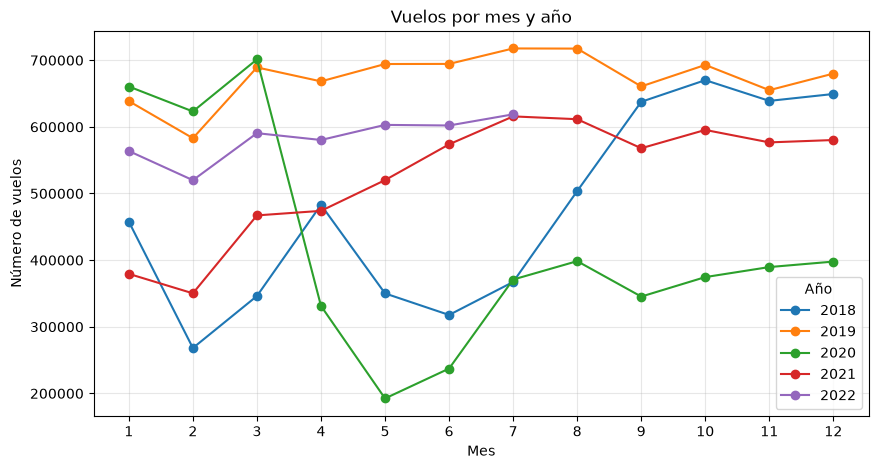

In [14]:
# Mismo dato en gráfico: vuelos por mes, una línea por año
tabla_cobertura.T.plot(marker="o", figsize=(10, 5))
plt.title("Vuelos por mes y año")
plt.xlabel("Mes")
plt.ylabel("Número de vuelos")
plt.xticks(range(1, 13))
plt.legend(title="Año")
plt.grid(alpha=0.3)
plt.show()

**Análisis:**

- **Faltan las columnas de causa de retraso** (`CarrierDelay`, `WeatherDelay`, `NASDelay`, `LateAircraftDelay`) y las de desvíos (`Div1...Div5`). Con esta versión del dataset podemos estudiar **cuándo y dónde** hay retrasos, pero **no por qué**.
- **2022 solo cubre enero a julio.** Agosto a diciembre no tienen datos. Un porcentaje anual de 2022 no es comparable con el de un año completo.
- **2018 tiene muchos menos vuelos de enero a agosto** que 2019 (por ejemplo, febrero: 268 mil contra 583 mil). A partir de septiembre de 2018 el volumen se normaliza (≈ 640 – 670 mil por mes). Es un hueco en los datos, no una caída real del tráfico, aunque la causa aún no está clara (se investiga en la sección 11).
- **2020 muestra el efecto de la pandemia:** abril, mayo y junio caen a 331 mil, 192 mil y 237 mil vuelos (en mayo de 2019 hubo 694 mil), y el resto del año no se recupera.
- **2019 es el único año sin anomalías** y sirve de referencia de un año "normal".

## 8. Vuelos, cancelaciones y desvíos por año

**Por qué:** las cancelaciones y los desvíos son otra forma de mala puntualidad, distinta del retraso. Medimos qué proporción de los vuelos programados no se completó cada año.

In [15]:
por_anio = duckdb.sql(f"""
    SELECT
        Year,
        COUNT(*)                                        AS vuelos,
        ROUND(100 * AVG(CAST(Cancelled AS INT)), 2)     AS pct_cancelados,
        ROUND(100 * AVG(CAST(Diverted  AS INT)), 2)     AS pct_desviados
    FROM '{ruta}'
    GROUP BY Year
    ORDER BY Year
""").df()

por_anio

,Year,vuelos,pct_cancelados,pct_desviados
0,2018,5689512,1.55,0.25
1,2019,8091684,1.90,0.26
2,2020,5022397,5.99,0.17
3,2021,6311871,1.76,0.24
4,2022,4078318,3.02,0.25


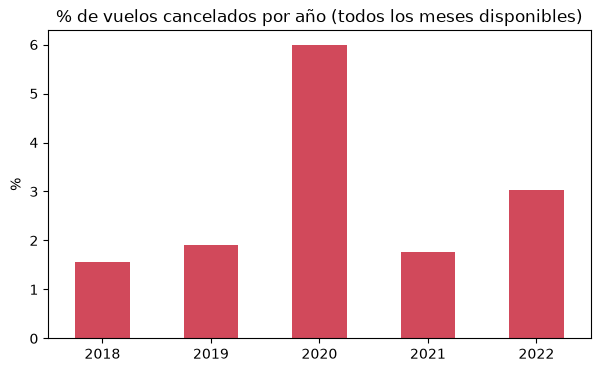

In [16]:
por_anio.set_index("Year")["pct_cancelados"].plot(kind="bar", figsize=(7, 4), color="#d1495b")
plt.title("% de vuelos cancelados por año (todos los meses disponibles)")
plt.ylabel("%")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()

**Análisis:**

- **2020 es el año con más cancelaciones: 5.99%**, más de tres veces el nivel de 2018 (1.55%) y 2019 (1.90%). Es consistente con las restricciones de la pandemia.
- **2022 también es alto (3.02%)**, aunque solo tiene siete meses de datos. Hay que verificar si ese valor se mantiene al comparar solo los mismos meses entre años (sección 12).
- Los **desvíos son muy estables**: entre 0.17% y 0.26% todos los años. Son un fenómeno raro y poco sensible al contexto.

## 9. Base de análisis: vuelos operados

**Por qué:** para medir retrasos solo tienen sentido los vuelos que **despegaron y llegaron a su destino**. Un vuelo cancelado no tiene retraso de llegada, y uno desviado no aterrizó donde estaba programado. Creamos una **vista** de DuckDB: no duplica los datos, solo guarda el filtro, y cada consulta posterior la usa como si fuera una tabla.

In [17]:
duckdb.sql(f"""
    CREATE OR REPLACE VIEW vuelos_operados AS
    SELECT *
    FROM '{ruta}'
    WHERE Cancelled = FALSE AND Diverted = FALSE
""")

duckdb.sql("""
    SELECT
        COUNT(*)                            AS vuelos_operados,
        SUM(CAST(ArrDelay IS NULL AS INT))  AS sin_ArrDelay
    FROM vuelos_operados
""").df()

,vuelos_operados,sin_ArrDelay
0,28348168,569.0


**Análisis:**

- La base de retrasos tiene **28,348,168 vuelos**, el 97.1% del total.
- Solo **569 vuelos operados** no tienen `ArrDelay`, un 0.002%. Es insignificante y las funciones de promedio los ignoran automáticamente, así que no hace falta tratarlos.
- A partir de aquí, **los análisis de retrasos usan `vuelos_operados`** y los de cancelaciones usan el parquet completo.

## 10. Retrasos por año

**Por qué:** es la primera medida de puntualidad. Usamos dos indicadores:

- **Retraso medio de llegada** en minutos (los valores negativos significan llegar antes de lo programado).
- **% de vuelos con 15 minutos o más de retraso** (`ArrDel15`), la definición oficial de "vuelo retrasado" en EE. UU.

In [18]:
retrasos_anio = duckdb.sql("""
    SELECT
        Year,
        COUNT(*)                          AS vuelos,
        ROUND(AVG(ArrDelay), 1)           AS retraso_medio_min,
        ROUND(100 * AVG(ArrDel15), 1)     AS pct_retrasados_15min
    FROM vuelos_operados
    GROUP BY Year
    ORDER BY Year
""").df()

retrasos_anio

,Year,vuelos,retraso_medio_min,pct_retrasados_15min
0,2018,5587186,5.4,19.5
1,2019,7917264,5.7,19.3
2,2020,4712931,-4.9,10.0
3,2021,6185871,3.3,17.3
4,2022,3944916,7.5,21.6


**Análisis:**

| Año | Retraso medio (min) | % retrasados (≥ 15 min) |
|---|---|---|
| 2018 | 5.4 | 19.5% |
| 2019 | 5.7 | 19.3% |
| 2020 | -4.9 | 10.0% |
| 2021 | 3.3 | 17.3% |
| 2022 | 7.5 | 21.6% |

- **2018 y 2019 son muy parecidos** (≈ 19% de vuelos retrasados y 5 a 6 minutos de retraso medio). Este es el comportamiento "normal" antes de la pandemia.
- **2020 es un caso extremo:** los vuelos llegaron en promedio **casi 5 minutos antes** de lo programado y solo el 10% se retrasó. Con menos tráfico, los aeropuertos y el espacio aéreo estaban despejados. **Menos retrasos en 2020 no significa mejor servicio**, sino cielos vacíos.
- **2022 es el peor año (21.6%, 7.5 min)**, pero **no se puede comparar directamente**: solo incluye enero a julio, y los meses de verano suelen tener más retrasos. La sección 12 corrige esto.
- **2018 también tiene un problema de cobertura** (sección 7), así que sus valores pueden estar sesgados.

## 11. Diagnóstico: ¿por qué 2018 tiene menos vuelos?

**Por qué:** de enero a agosto de 2018 hay entre 28% y 54% menos vuelos que en esos mismos meses de 2019. Si el hueco se concentra en una o dos aerolíneas, entenderemos la causa y sabremos si los porcentajes de 2018 son confiables. Si afecta a todas por igual, el faltante es más bien general.

La consulta compara, aerolínea por aerolínea, el número de vuelos de enero a agosto de 2018 y de 2019. La columna `razon_2018_vs_2019` vale 1 si no hubo cambio, 0.5 si 2018 tiene la mitad, y vacía si la aerolínea no existía en 2019.

In [19]:
duckdb.sql(f"""
    SELECT
        Airline,
        SUM(CASE WHEN Year = 2018 THEN 1 ELSE 0 END)  AS vuelos_2018,
        SUM(CASE WHEN Year = 2019 THEN 1 ELSE 0 END)  AS vuelos_2019,
        ROUND(SUM(CASE WHEN Year = 2018 THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN Year = 2019 THEN 1 ELSE 0 END), 0), 2) AS razon_2018_vs_2019
    FROM '{ruta}'
    WHERE Month <= 8 AND Year IN (2018, 2019)
    GROUP BY Airline
    ORDER BY vuelos_2019 DESC
""").df()

,Airline,vuelos_2018,vuelos_2019,razon_2018_vs_2019
0,Southwest Airlines Co.,905666.0,914556.0,0.99
1,Delta Air Lines Inc.,150267.0,662349.0,0.23
2,American Airlines Inc.,80406.0,631114.0,0.13
3,SkyWest Airlines Inc.,275399.0,556584.0,0.49
4,United Air Lines Inc.,409773.0,417344.0,0.98
5,Envoy Air,26434.0,218703.0,0.12
6,Republic Airlines,99848.0,217279.0,0.46
7,JetBlue Airways,205721.0,198451.0,1.04
8,Comair Inc.,24387.0,192923.0,0.13
9,Alaska Airlines Inc.,100539.0,177886.0,0.57


**Análisis:**

El deficit de vuelos entre enero y agosto de 2018 no responde a un recorte generalizado de los vuelos en el mercado. Sino, a caidas  drasticas y puntuales en aerolineas especificas como *Delta*, *American Airlines*, *Comair* y *Envoy*, y a la ausencia de datos o cese de operaciones de otras como *Virgin America* y *Cape Air* en comparacion con 2019.

## 12. Base comparable: enero a julio

**Por qué:** los únicos meses que existen en **los cinco años** son enero a julio (2022 termina en julio). Si limitamos el análisis a esos meses, cada año se compara contra el mismo periodo del calendario y la estacionalidad deja de distorsionar los resultados. Creamos una nueva vista con esa restricción y repetimos las medidas de las secciones 8 y 10.

In [20]:
duckdb.sql("""
    CREATE OR REPLACE VIEW vuelos_comparables AS
    SELECT *
    FROM vuelos_operados
    WHERE Month <= 7
""")

retrasos_comparables = duckdb.sql("""
    SELECT
        Year,
        COUNT(*)                          AS vuelos,
        ROUND(AVG(ArrDelay), 1)           AS retraso_medio_min,
        ROUND(100 * AVG(ArrDel15), 1)     AS pct_retrasados_15min
    FROM vuelos_comparables
    GROUP BY Year
    ORDER BY Year
""").df()

retrasos_comparables

,Year,vuelos,retraso_medio_min,pct_retrasados_15min
0,2018,2536939,5.8,20.1
1,2019,4561236,7.2,20.6
2,2020,2825590,-4.5,11.0
3,2021,3317115,2.3,16.2
4,2022,3944916,7.5,21.6


In [21]:
cancelaciones_comparables = duckdb.sql(f"""
    SELECT
        Year,
        COUNT(*)                                        AS vuelos,
        ROUND(100 * AVG(CAST(Cancelled AS INT)), 2)     AS pct_cancelados
    FROM '{ruta}'
    WHERE Month <= 7
    GROUP BY Year
    ORDER BY Year
""").df()

cancelaciones_comparables

,Year,vuelos,pct_cancelados
0,2018,2589886,1.79
1,2019,4685559,2.36
2,2020,3116706,9.17
3,2021,3380157,1.61
4,2022,4078318,3.02


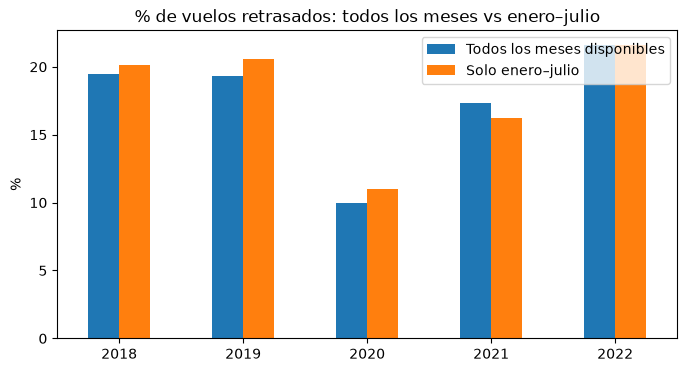

In [22]:
# Comparación gráfica: todos los meses disponibles vs solo enero–julio
comparacion = retrasos_anio.set_index("Year")[["pct_retrasados_15min"]] \
    .join(retrasos_comparables.set_index("Year")[["pct_retrasados_15min"]],
          lsuffix="_todos_los_meses", rsuffix="_ene_jul")

comparacion.plot(kind="bar", figsize=(8, 4))
plt.title("% de vuelos retrasados: todos los meses vs enero–julio")
plt.ylabel("%")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(["Todos los meses disponibles", "Solo enero–julio"])
plt.show()

**Análisis** 

Al restringir el análisis al periodo homogéneo de enero a julio, el porcentaje de retrasados en 2022 se mantiene exactamente igual en 21.6%. Esto ocurre porque el año 2022 en la fuente de datos original ya venía limitado por defecto hasta el mes de julio, por lo que el filtro no eliminó ningún mes adicional y sus cifras se conservaron intactas. En la misma línea, la alta tasa de cancelación de 2022 se mantiene en 3.02%, confirmando que no se trataba de un espejismo estacional del verano, sino de un problema estructural de ese año operativo. Por el contrario, los valores de 2018 sí cambian de manera notable al recortar la base: el número de vuelos analizados pasa de 5.58 a 2.53 millones, el porcentaje de retrasos asciende de 19.5% a 20.1% y el retraso medio sube de 5.4 a 5.8 minutos, lo que demuestra que los meses excluidos de 2018 poseían un comportamiento diferente y que alinear el periodo calendario corrige dicha distorsión. Finalmente, 2020 sigue destacando de forma radical como el año más atípico, registrando el menor porcentaje de retrasos con un 11.0%, un promedio de llegada anticipada de -4.5 minutos debido a la escasez de tráfico aéreo y un pico histórico de cancelaciones del 9.17%

## 13 Retrasos y cancelaciones por mes

Es necesario entender llos patrones de estacionalidad de los retrasos y cancelaciones delos vuelos para comprender el comportaminento historico de las aerolineas y evitar sesgos en la evaluacion de la puntualidad y rendimiento del servicio.

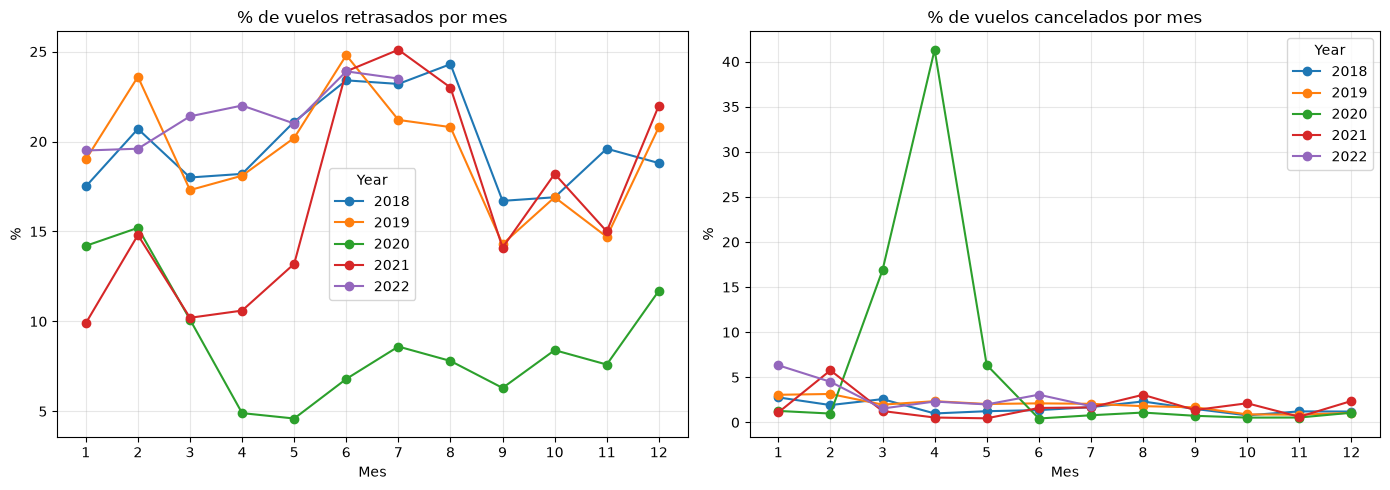

In [27]:
por_mes = duckdb.sql("""
    SELECT
        Year, Month,
        ROUND(100 * AVG(ArrDel15) FILTER (WHERE NOT Cancelled AND NOT Diverted), 1) AS pct_retrasados,
        ROUND(100 * AVG(CAST(Cancelled AS INT)), 2)                                AS pct_cancelados
    FROM vuelos_listos
    GROUP BY Year, Month
    ORDER BY Year, Month
""").df()

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
por_mes.pivot(index="Month", columns="Year", values="pct_retrasados").plot(marker="o", ax=ejes[0])
ejes[0].set_title("% de vuelos retrasados por mes")
por_mes.pivot(index="Month", columns="Year", values="pct_cancelados").plot(marker="o", ax=ejes[1])
ejes[1].set_title("% de vuelos cancelados por mes")
for eje in ejes:
    eje.set_xlabel("Mes"); eje.set_ylabel("%"); eje.set_xticks(range(1, 13)); eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Análisis:** 

El grafico izquierdo `% de vuelos retrasados por mes` destaca por la evidencia de un comportamiento estacional marcado en los años operativos normales (excluyendo 2020) corresppondiente a los meses de verano (entre junio y agosto). Donde se registran picos en la tasa de retrasos en vuelos lo cual podria ser explicado por el aumento de loos vuelos y la congestion en el espacio aereo. Por otro lado, el grafico derecho `% de vuelos cancelados por mes` evidencia un comportamiento estable en la tasa de cancelaciones de vuelos por mes en todos los periodos exclutendo al año *2020* donde el porcentaje de cancelaciones se dspara a mas del 40% debido a las cancelaciones ocasionadas por la pandemia.

## 14. Aeropuertos con mayor porcentaje de cancelaciones y retrasos 

Filtrando por aeropuertos con mas de **5000 vuelos **permite discernir entre la alta variabilidad de aeropuertos de menor tamaño y la congestión estructural que padecen los grandes hubs, aportando información indispensable para entender los puntos de quiebre en la red de transporte aéreo

In [29]:

# Identificar aeropuertos con mayores tasas de retraso y cancelación
aeropuertos_criticos = duckdb.sql("""
    SELECT 
        Origin AS Aeropuerto,
        COUNT(*) AS total_vuelos,
        ROUND(100 * AVG(CAST(Cancelled AS INT)), 2) AS pct_cancelados,
        ROUND(100 * AVG(ArrDel15) FILTER (WHERE NOT Cancelled AND NOT Diverted), 2) AS pct_retrasados_15min
    FROM vuelos_listos
    GROUP BY Origin
    HAVING COUNT(*) > 5000  -- Opcional: filtra aeropuertos pequeños para evitar sesgos por volumen bajo
    ORDER BY pct_retrasados_15min DESC
    LIMIT 15
""").df()

aeropuertos_criticos

,Aeropuerto,total_vuelos,pct_cancelados,pct_retrasados_15min
0,LCK,5023,4.60,31.07
1,BLV,5252,4.40,30.04
2,USA,5294,6.48,28.80
3,TTN,10258,3.65,27.35
4,ASE,26972,8.59,26.75
5,BQN,7769,2.29,26.74
6,SWF,7099,3.94,25.86
7,ACK,6095,5.07,25.06
8,EWR,578014,4.17,24.96
9,HPN,38785,3.76,22.58


El análisis de los aeropuertos críticos revela que las tasas más altas de retrasos superiores a 15 minutos se concentran en terminales con volúmenes moderados como LCK (31.07%), BLV (30.04%) y USA (28.8%). Sin embargo, el hallazgo más relevante desde una perspectiva sistémica es el caso de EWR (Newark), que combina un volumen masivo de 578,014 operaciones con una tasa de retrasos del 24.96%, evidenciando cómo los grandes nudos de conexión sufren cuellos de botella operativos a gran escala. Asimismo, en cuanto a la fiabilidad del servicio, destaca el aeropuerto de ASE (Aspen) con la tasa de cancelación más elevada del grupo (8.59%) en un volumen considerable de más de 26,000 vuelos, un comportamiento típico de terminales con retos geográficos y meteorológicos complejos.

## 15. Aerolineas con mayor porcentaje de cancelaciones y retrasos 

Se realiza fundamentalmente para identificar qué operadores presentan mayores problemas de puntualidad o tasas críticas de cancelación, lo que ayuda a distinguir si las fallas en el transporte aéreo provienen de una congestión general de la infraestructura o de problemas internos de gestión, mantenimiento y planificación de cada compañía.

In [30]:
aerolineas_criticas = duckdb.sql("""
    SELECT 
        Airline AS Aerolinea,
        COUNT(*) AS total_vuelos,
        ROUND(100 * AVG(CAST(Cancelled AS INT)), 2) AS pct_cancelados,
        ROUND(100 * AVG(ArrDel15) FILTER (WHERE NOT Cancelled AND NOT Diverted), 2) AS pct_retrasados_15min
    FROM vuelos_listos
    GROUP BY Airline
    HAVING COUNT(*) > 10000  -- Filtra aerolíneas con bajo volumen para evitar sesgos
    ORDER BY pct_retrasados_15min DESC
    LIMIT 15
""").df()

aerolineas_criticas

,Aerolinea,total_vuelos,pct_cancelados,pct_retrasados_15min
0,"Commutair Aka Champlain Enterprises, Inc.",260048,4.23,26.29
1,Trans States Airlines,161590,4.09,25.64
2,JetBlue Airways,1106079,2.63,25.61
3,Allegiant Air,489400,4.58,24.52
4,Frontier Airlines Inc.,570452,2.41,24.29
5,ExpressJet Airlines Inc.,353669,4.06,21.55
6,Virgin America,17670,2.45,20.05
7,"GoJet Airlines, LLC d/b/a United Express",276486,3.34,19.91
8,Mesa Airlines Inc.,749216,3.44,19.17
9,Spirit Air Lines,836694,2.17,19.09


**Analisis:** 

Al revisar las aerolíneas con más retrasos y cancelaciones, vemos que el problema no discrimina tamaño. Por un lado, las aerolíneas regionales o medianas como Commutair (26.29%), Trans States Airlines (25.64%) y JetBlue Airways (25.61%) encabezan la lista con los mayores porcentajes de retrasos superiores a 15 minutos, superando la cuarta parte de sus vuelos. Por otro lado, gigantes como American, United y Southwest, aunque manejan porcentajes de retraso un poco más bajos (alrededor del 18%), mueven millones de pasajeros, lo que significa que arrastran un volumen masivo de demoras. En cuanto a las cancelaciones, la mayoría se mantiene estable entre el 2% y el 4%, con algunos picos ligeros en operadores regionales.

## 16. Correlacion entre retrasos de Salida, retrasos de llegada, rodaje y distancia


* Coeficiente de Pearson: Se implementó como primera medida para evaluar relaciones lineales directas utilizando los valores numéricos exactos de las variables. Sin embargo, en bases de datos masivas de aviación, los retrasos extremos (outliers) pueden distorsionar fuertemente los resultados.

* Coeficiente de Spearman: Se incorporó como una alternativa complementaria y más robusta. Al trabajar con rangos (posiciones) en lugar de los valores crudos, Spearman neutraliza el efecto de los valores atípicos y permite capturar relaciones monótonas de manera más fiel cuando los datos no se distribuyen de forma perfectamente lineal.

###  Usando Coeficiente de Pearson

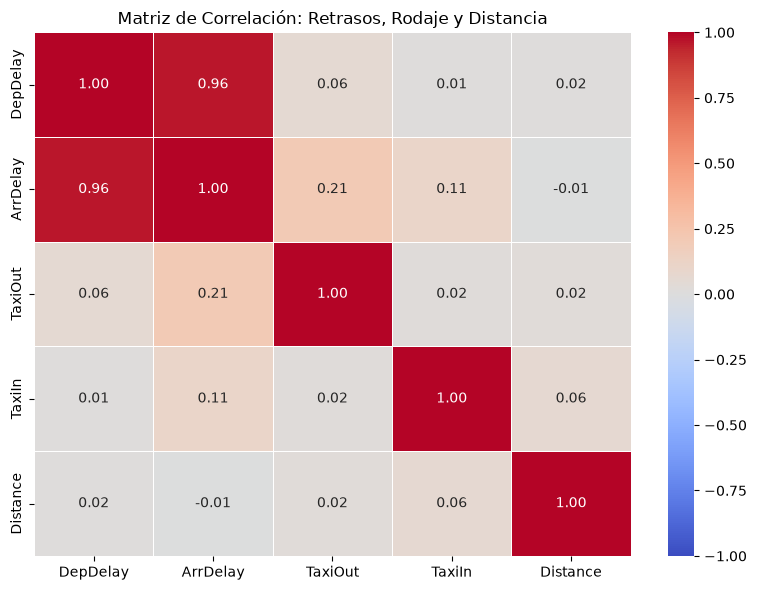

,DepDelay,ArrDelay,TaxiOut,TaxiIn,Distance
DepDelay,1.000000,0.962520,0.057043,0.014839,0.015113
ArrDelay,0.962520,1.000000,0.206125,0.105779,-0.007446
TaxiOut,0.057043,0.206125,1.000000,0.021965,0.023783
TaxiIn,0.014839,0.105779,0.021965,1.000000,0.064417
Distance,0.015113,-0.007446,0.023783,0.064417,1.000000


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

# 1. Extraer las variables de interés en un DataFrame de Pandas
df_corr = duckdb.sql("""
    SELECT 
        DepDelay,
        ArrDelay,
        TaxiOut,
        TaxiIn,
        Distance
    FROM vuelos_listos
    WHERE NOT Cancelled AND NOT Diverted
""").df()

# 2. Calcular la matriz de correlación (por defecto usa Pearson)
matriz_corr = df_corr.corr()

# 3. Visualizar la matriz con un mapa de calor (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlación: Retrasos, Rodaje y Distancia")
plt.tight_layout()
plt.show()

matriz_corr

###  Usando Coeficiente de Spearman

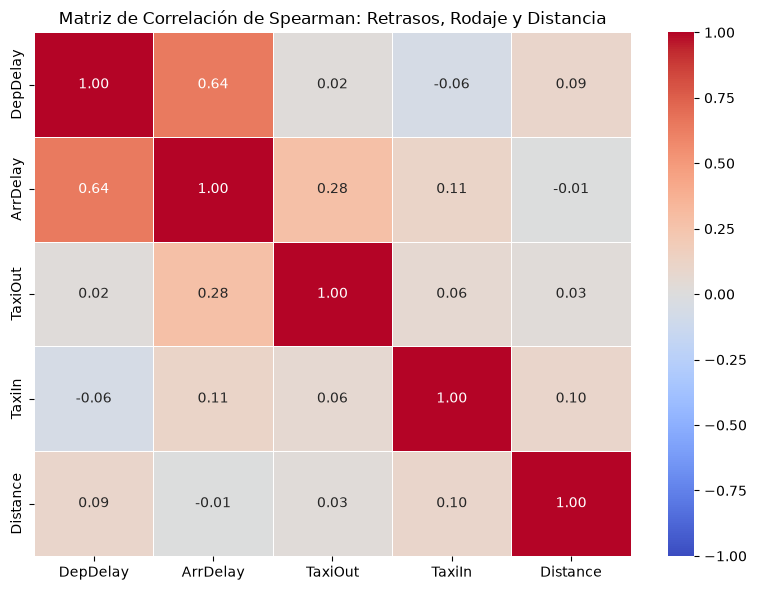

In [32]:
# 1. Calcular la matriz de correlación usando Spearman
matriz_corr_spearman = df_corr.corr(method='spearman')

# 2. Visualizar con el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr_spearman, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlación de Spearman: Retrasos, Rodaje y Distancia")
plt.tight_layout()
plt.show()

**Análisis:**

* Fuerte correlación entre salidas y llegadas: Tanto en `Pearson (0.96)` como en `Spearman (0.64)`, se observa la relación más fuerte del sistema entre el retraso de salida (DepDelay) y el retraso de llegada (ArrDelay), confirmando que un vuelo que despega tarde difícilmente recupera el tiempo en el aire.

* Impacto leve del rodaje (TaxiOut): El tiempo de rodaje en salida muestra una correlación moderada-baja con los retrasos de llegada `(0.21 en Pearson y 0.28 en Spearman)`, lo que indica que la congestión en pistas terrestres contribuye a las demoras, aunque no es el único factor determinante.

* Independencia de la distancia: La distancia del vuelo (Distance) muestra correlaciones cercanas a cero con los retrasos y los tiempos de rodaje, demostrando que la duración o longitud de la ruta no es un detonante directo de que un vuelo vaya a salir o llegar demorado.